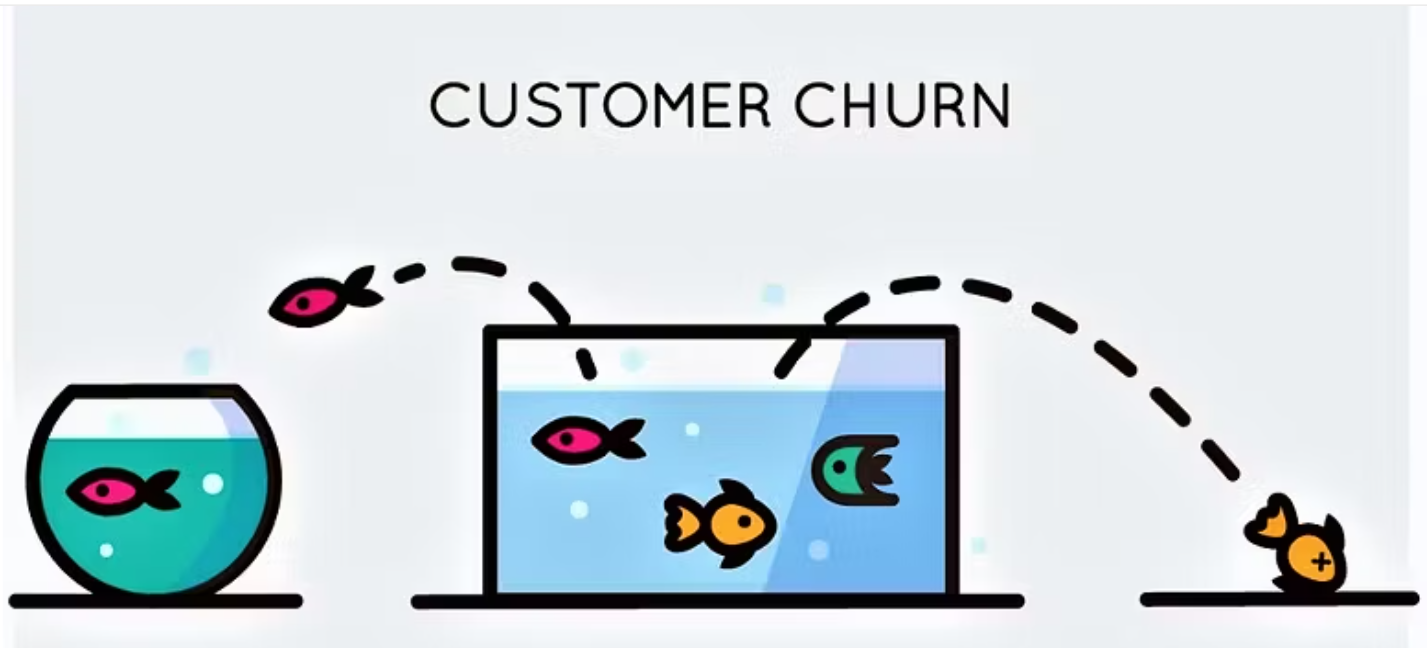

#                                                           CUSTOMER CHURN PREDICTION

# Problem
- In a Telecom Company We are losing customers. We don’t know who will leave next. Hence find out which customers will Stay & which customers will Leave..

# My Goal
- As a DataScientist , Im responsible to build a ML Model that can accurately calssify whether the exisisting customer will Stay or Leave . This is called Customer Churn Analysis 

# Why should I do this Analysis? Wt is the Need?
## When Im running a Company , My Customers are my Income . More the customers , more the income . So the existing customers are GOLD for me, finding new customers is pretty Expensive , Time Consuming & difficult process. 
- Because of Competations,Less Customer satisfaction,Ineffective customer support system my customers might leave my organization and might be willing to try something New .
- Hence By using this ML Classification Model , I can clearly group customers who will stay & who will leave so that I can perform Targeted Marketting , Provide Offers,Discounts to only those customers who's most probably will leave my Organization & also provide Loyality discounts for the customers who most probably will Stay at my Org.
- In this way I can retain my customers back to my organization , give them more Trust & Comfort to stay at my Org , Thereby Increasing the Company Growth,Income,Customer Trust & Company Reputation.
    

# Project Overview Diagram:

<mark> Initial Steps </mark>
- Loading Data
<mark> EDA </mark>
- Basic Data Understanding
- Data Dictionary
- Initial Data Checks
- Univariant Analysis
- Bivariant Analysis
- Multivariant Analysis
- Data Cleaning
- Feature Selection
- Feature Transformation
- Feature Scaling
- Final Data Preparation -> Clean Data to send to a Model
<mark> Model Building </mark>

# Initial Step: Loading Dataset


In [4]:
import pandas as pd
df=pd.read_csv("Telecom Churn Analysis.csv")
df.head()
#problem: I can't see all the columns in the df so -> use pd.set_option('display.max_col',None)
pd.set_option('display.max_columns',None)



In [5]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# EDA
## Step 1 : Basic Data Understanding
* Check shape, columns, data types, basic info
* Identify target variable

- df.shape
- df.size
- df.isnull().sum()
- df.duplicated()
- df.info()
- df.describe()

In [4]:
df.shape
#I have 7,043 Rows -> each Row = 1 customer details 
#I've 21 Features : for Churn Analysis 


(7043, 21)

In [5]:
df.size

# More the data -> more accurate predictions 

147903

In [6]:
df.info()

#insights :

# 1. There are totally : 7043 Rows & 21 Col
# 2. There is No NULL Values in all the 21 Rows -> clean Dataset
# 3. The Data type of TotalCharges should be float & not object  -> So Convert it from object ->float
# 4. Churn Col -> Dependent Variable & rest of the other col are : Independent Variables

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [123]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2281.916928
std,0.368612,24.559481,30.090047,2265.270398
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,402.225000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


# EDA
# Step 2 : Data Dictionary

* Understand meaning of each column
* Connect features with business context

#  DATA DICTIONARY (WITH BUSINESS INSIGHT)

| Column Name          | Meaning                          | How it Helps in Business Insights                                      |
| -------------------- | -------------------------------- | ---------------------------------------------------------------------- |
| **customerID**       | Unique ID for each customer      | ❌ No analytical value → used only for identification (will drop later) |
| **gender**           | Male / Female                    | Helps check if churn depends on gender                                 |
| **SeniorCitizen**    | 1 = Yes, 0 = No                  | Helps identify if older customers churn more                           |
| **Partner**          | Whether customer has a partner   | Helps understand stability (family customers may stay longer)          |
| **Dependents**       | Whether customer has dependents  | Customers with dependents may churn less                               |
| **tenure**           | Number of months customer stayed | 🔥 Very important → lower tenure = higher churn risk                   |
| **PhoneService**     | Has phone service or not         | Helps understand service usage                                         |
| **MultipleLines**    | Multiple phone lines or not      | Higher usage → may reduce churn                                        |
| **InternetService**  | DSL / Fiber / No                 | Helps compare churn across service types                               |
| **OnlineSecurity**   | Has security service or not      | More services → less churn                                             |
| **OnlineBackup**     | Backup service usage             | Engagement indicator                                                   |
| **DeviceProtection** | Device protection service        | Value-added service → reduces churn                                    |
| **TechSupport**      | Has tech support                 | Customers with support → more satisfied                                |
| **StreamingTV**      | Uses TV streaming                | Entertainment usage pattern                                            |
| **StreamingMovies**  | Uses movie streaming             | Helps understand engagement                                            |
| **Contract**         | Month-to-month / 1 yr / 2 yr     | 🔥 Strong predictor → short contract = high churn                      |
| **PaperlessBilling** | Uses paperless billing           | Digital behavior insight                                               |
| **PaymentMethod**    | Payment type                     | Some methods → higher churn risk                                       |
| **MonthlyCharges**   | Monthly bill amount              | 🔥 High charges may increase churn                                     |
| **TotalCharges**     | Total money spent                | Indicates long-term customer value                                     |
| **Churn** 🎯         | Target (Yes/No)                  | What we are trying to predict                                          |


# EDA
# Step 3: Initial Data Checks
* Check missing values
* Check duplicates
* Identify incorrect data types

In [82]:
# Lets Convert TotalCharges -> object Data type into -> numeric data type 
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].head()

0      29.85
1    1889.50
2     108.15
3    1840.75
4     151.65
Name: TotalCharges, dtype: float64

In [83]:
df.isnull().sum()
#insight :  Under col : TotalCharges -> 11 null values 

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

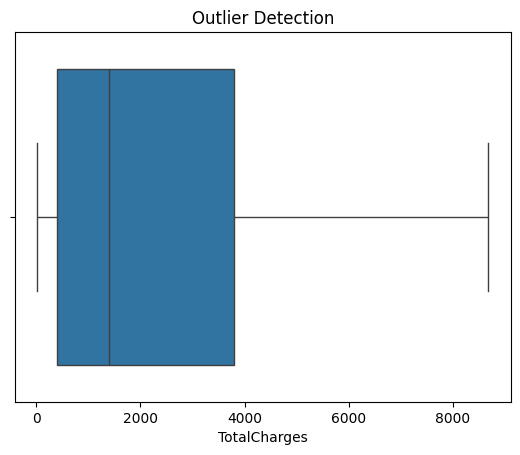

In [84]:
# Now after know that we have null values -> we need to fill those null values with the right value -> Outlier Detectection 

import matplotlib.pyplot as plt
import seaborn as sns 

sns.boxplot(x=df['TotalCharges'])
plt.title("Outlier Detection")
plt.show()

#insight : I see that its a Positive Skew from the Boxplot -> So use Median to fill the null values 

In [ ]:
m=df['TotalCharges'].median()
df['TotalCharges'].fillna(m,inplace=True)

In [86]:
# lets verify is there any null values or not  
df['TotalCharges'].isnull().sum()

#insight: There is No null values -> proceed further 

np.int64(0)

In [87]:
df.duplicated().sum()

#insight : No Duplicates , Clean Dataset 

np.int64(0)

# Step 4: EDA


## Complete EDA Process (Start → End)



## 1. Data Understanding





## 2. Data Dictionary





## 3.
















## 7. Data Cleaning

* Fix data types
* Handle missing values
* Remove duplicates (if any)
* Handle outliers (if needed)



## 8. Feature Selection

* Remove irrelevant columns (like IDs)
* Drop low-impact features (optional)
* Keep important features based on analysis



## 9. Feature Transformation

* Encode categorical variables (Label / One-hot encoding)
* Convert target variable to numeric



## 10. Feature Scaling

* Normalize/standardize numerical features (if required)



## 11. Final Data Preparation

* Define X (features) and y (target)
* Train-test split



# ## Where EDA Ends

👉 EDA ends after:

* Data is clean
* Features are selected
* Data is ready for modeling



# ## What Comes After EDA

* Model Building
* Model Evaluation
* Model Improvement




# EDA 
## Target Analysis 

- To Know whether the Target Col is Balanced / Imbalanced
- How it will affect the Model's Prediction (Biased)
- Model Accuracy (fake accuracy so use metrics : Confusion Matrics,precision,relacll etc)

In [18]:
df['Churn'].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

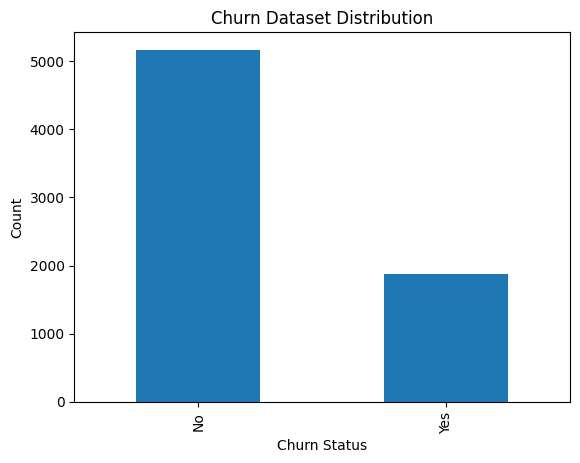

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df['Churn'].value_counts().plot(kind="bar")
plt.title("Churn Dataset Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Count")
plt.show()


#Insight : Imbalanced Dataset 

#1. Target variable -> Churn Col -> is NOT BALANCED
#2. No -> 5174 & yes ->1869
#3. How imbalanced data will affect the Model -> the model will make BIASED Decisions -> more high Priority to : No -> Inaccurate model Prediction 



<mark>“The dataset is moderately imbalanced (73% non-churn, 27% churn). This can lead the model to be biased toward the majority class, making accuracy an unreliable metric. Therefore, we should focus on metrics like precision, recall, and F1-score.”</mark>

# EDA
## Step 4 : Univariate Analysis

* Analyze each column individually
* For numerical → distribution, skewness, outliers
* For categorical → value counts, imbalance

## Automating Univariant Analysis 

- Steps to perform is :
1. Divide your DF Columns into 2 categories:
a)Numerical Col
b)Categoral Col
2. Create 2 functions seperately for Numerical & Categoral
3. Numerical Fun: Find the following
- Unique values in that col
- Mean,Median,Mode
- Data Distribution : SKewed/Normal
- If elif Condition
- Null values present?

4. Categoral Fun : Find the following
- unique values 
- Balanced or not
  

In [39]:
# Lets Divide the Col in our DataFrame
# Before that remove Customer_id Col , add Senior Citizen col to cat Col 
#num Col
num_col=df.select_dtypes(include=['int64','float64']).columns.to_list()

print(num_col)

#Categoral Col
cat_col=df.select_dtypes(include=['object']).columns.to_list()
print(cat_col)

['SeniorCitizen', 'tenure', 'MonthlyCharges']
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
num_col.remove('SeniorCitizen')

In [93]:
cat_col.remove('customerID')

In [96]:
cat_col.append('SeniorCitizen')

In [101]:
df['TotalCharges'].dtypes

dtype('float64')

In [95]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Col Name :tenure

 Unique Values in tenure are:[ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
Mean :32.37114865824223
Median :29.0
Mode :0    1
Name: tenure, dtype: int64


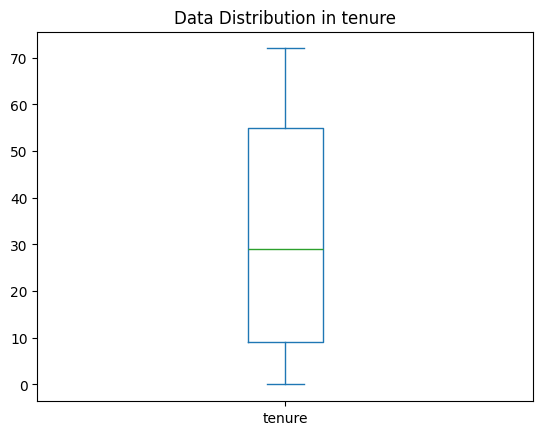

Skewness of tenure: 0.24
Approximately Normally Distributed
IQR Outlier Detection Method
Outliers are :  0
Null Values
No Null Values in this tenure
****************************************************************************************************
Col Name :MonthlyCharges

 Unique Values in MonthlyCharges are:[29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
Mean :64.76169246059918
Median :70.35
Mode :0    20.05
Name: MonthlyCharges, dtype: float64


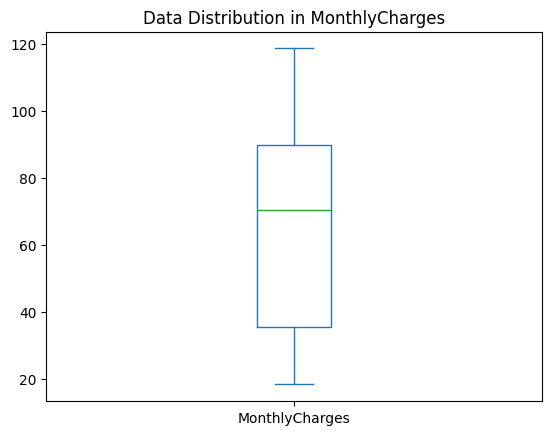

Skewness of MonthlyCharges: -0.22
Approximately Normally Distributed
IQR Outlier Detection Method
Outliers are :  0
Null Values
No Null Values in this MonthlyCharges
****************************************************************************************************
Col Name :TotalCharges

 Unique Values in TotalCharges are:[  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Mean :2281.9169281556156
Median :1397.475
Mode :0      20.200
1    1397.475
Name: TotalCharges, dtype: float64


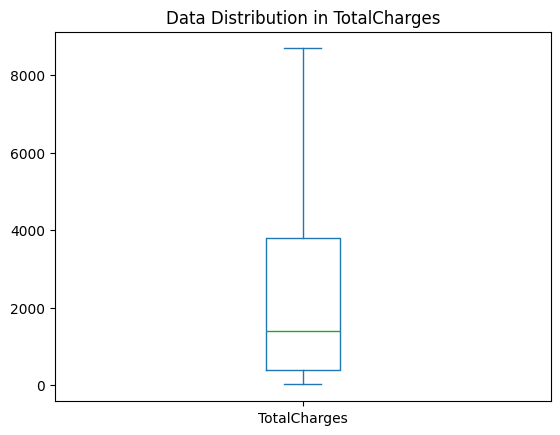

Skewness of TotalCharges: 0.96
Positively Skewed
IQR Outlier Detection Method
Outliers are :  0
Null Values
No Null Values in this TotalCharges
****************************************************************************************************


In [143]:
# Creating Function -> Numerical Col

def uni_num_col(df):
    for col in num_col:
        #Col Name
        print(f"Col Name :{col}")
        
        # Unique Values
        print(f"\n Unique Values in {col} are:{df[col].unique()}")
        
        #Mean Median and Mode
        print(f"Mean :{df[col].mean()}")
        print(f"Median :{df[col].median()}")
        print(f"Mode :{df[col].mode()}")

        #Skewness 
        df[col].plot(kind='box')
        plt.title(f"Data Distribution in {col}")
        plt.show()

        skew = round(df[col].skew(), 2)

        print(f"Skewness of {col}: {skew}")
        
        if -0.5 <= skew <= 0.5:
            print("Approximately Normally Distributed")
        elif skew > 0.5:
            print("Positively Skewed")
        else:
            print("Negatively Skewed")
        

         #IQR Outliers
        print("IQR Outlier Detection Method")
        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)
        IQR=Q3-Q1
        lower_limit=Q1-1.5*IQR
        upper_limit=Q3+1.5*IQR 
        #df[() | ()]
        outliers=df[(df[col]<lower_limit)|(df[col]>upper_limit)]
        print("Outliers are : ",len(outliers))


        #Null Values

        print(f"Null Values")
        null=df[col].isnull().sum()
        if null==0:
            print("No Null Values in this",col)
        else:
            print("Yes , There are Null Values in this",col)

        print("*"*100)

uni_num_col(df)

In [144]:
# Creating a Function for Categoral Col

def uni_cat_col(df):
    for col in cat_col:
        # Col Name
        print(f"Col Name is : {col}")

        #Unique Values 
        print(f"Unique Values are : {df[col].unique()}")

        #Dataset Balanced / Not?
        print(f"Is Dataset Balanced / Not? \n{df[col].value_counts(normalize=True)*100}")

        #Missing Values 
        print(f"Missing Values in {col} is ")
        null=df[col].isnull().sum()
        if null==0:
            print("No, There are No Null Values")
        else:
            print("Yes, There are Null Values")

        print("*"*100)


uni_cat_col(df)


Col Name is : gender
Unique Values are : ['Female' 'Male']
Is Dataset Balanced / Not? 
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64
Missing Values in gender is 
No, There are No Null Values
****************************************************************************************************
Col Name is : Partner
Unique Values are : ['Yes' 'No']
Is Dataset Balanced / Not? 
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64
Missing Values in Partner is 
No, There are No Null Values
****************************************************************************************************
Col Name is : Dependents
Unique Values are : ['No' 'Yes']
Is Dataset Balanced / Not? 
Dependents
No     70.041176
Yes    29.958824
Name: proportion, dtype: float64
Missing Values in Dependents is 
No, There are No Null Values
****************************************************************************************************
Col Name is : PhoneService
Unique

# Univariate Analysis Insights

### tenure

* Average tenure is around 32 months, median is 29 months
* Data is normally distributed with no outliers
* Customers are evenly spread between new and long-term users
* Insight: No strong pattern alone, but **low tenure customers may have high churn risk (to be checked later)**

---

### MonthlyCharges

* Average monthly charge is around 64–70
* Data is approximately normally distributed
* Most customers fall in mid to high charge range
* Insight: Customers paying higher charges may expect better service → **potential medium churn risk**

---

### gender

* Male ≈ 50%, Female ≈ 50%
* Balanced distribution
* Insight: **Low impact feature**, not a strong predictor → can be considered less significant

---

### Partner

* Yes ≈ 48%, No ≈ 52%
* Nearly balanced
* Insight: May have **slight influence**, needs further validation with churn

---

### Dependents

* No ≈ 70%, Yes ≈ 30%
* Majority customers do not have dependents
* Insight: Customers without dependents may switch easily → **medium to high churn risk**

---

### PhoneService

* Yes ≈ 90%, No ≈ 10%
* Highly imbalanced
* Insight: Almost all customers use phone service → **low importance feature**, can be considered for removal

---

### MultipleLines

* No ≈ 48%, Yes ≈ 42%, No phone service ≈ 10%
* Fairly distributed
* Insight: May have **moderate impact**, needs further analysis

---

### InternetService

* Fiber optic ≈ 44%, DSL ≈ 34%, No ≈ 22%
* Insight: Different service types exist → **important feature for churn analysis**

---

### OnlineSecurity

* No ≈ 50%, Yes ≈ 29%, No internet ≈ 21%
* Insight: Customers without security services → **higher churn risk**

---

### OnlineBackup

* No ≈ 44%, Yes ≈ 34%, No internet ≈ 21%
* Insight: Lower engagement → **medium churn risk**

---

### DeviceProtection

* Similar distribution as backup
* Insight: Customers without protection → **medium churn risk**

---

### TechSupport

* No ≈ 49%, Yes ≈ 29%
* Insight: Lack of support → **high churn risk**

---

### StreamingTV / StreamingMovies

* Balanced between Yes and No (~39–38%)
* Insight: Moderate usage → **low to medium impact**

---

### Contract

* Month-to-month ≈ 55%, One year ≈ 21%, Two year ≈ 24%
* Insight: Majority are short-term customers → **high churn risk (very important feature)**

---

### PaperlessBilling

* Yes ≈ 59%, No ≈ 41%
* Insight: Slight skew → **low to medium impact**

---

### PaymentMethod

* Electronic check ≈ 33% (highest)
* Others around 21–22%
* Insight: Payment behavior varies → **potential churn indicator**

---

### TotalCharges

* Wide distribution across customers
* Insight: Indicates customer lifetime value → **important feature**

---

### Churn (Target Variable)

* No ≈ 73%, Yes ≈ 27%
* Dataset is imbalanced
* Insight: Model may become biased → **special handling required later**

---

### SeniorCitizen

* No ≈ 84%, Yes ≈ 16%
* Insight: Small group but may behave differently → **needs further analysis**


# EDA

## Step 5: Bivariate Analysis

* Compare each feature with target variable
* Identify patterns and important features
* Detect high/low impact variables

Helps in:
- Feature selection
- Model improvement
- Business decisions

<mark>=>VERY IMPORTANT RULE</mark>

- While analyzing each plot, always answer:

- Which category has highest churn?
- Why could that be happening?
- Is this feature important or not?

In [145]:
# Lets do Bivariant analysis for ->> Cat Col 
print(cat_col)
print(num_col)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn', 'SeniorCitizen']
['tenure', 'MonthlyCharges', 'TotalCharges']


## Bivariant Analysis - Cat Columns

gender Vs Churn


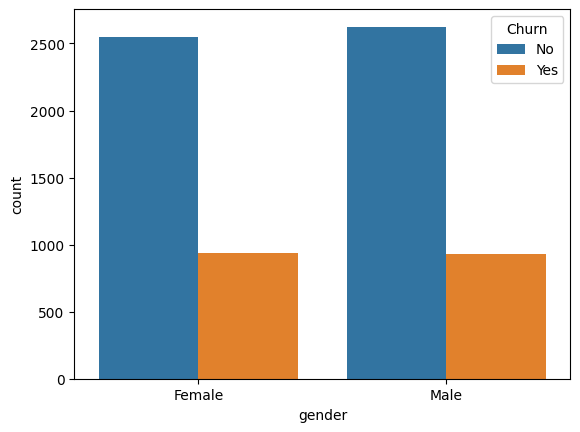

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338
****************************************************************************************************
Partner Vs Churn


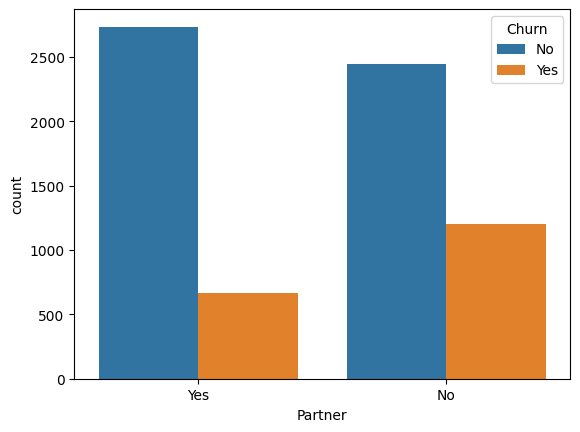

Churn           No        Yes
Partner                      
No       67.042021  32.957979
Yes      80.335097  19.664903
****************************************************************************************************
Dependents Vs Churn


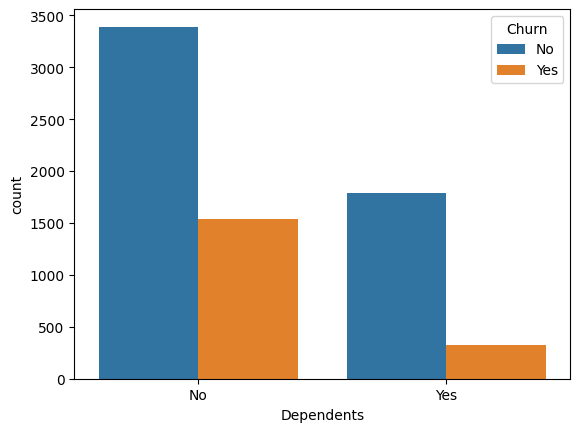

Churn              No        Yes
Dependents                      
No          68.720860  31.279140
Yes         84.549763  15.450237
****************************************************************************************************
PhoneService Vs Churn


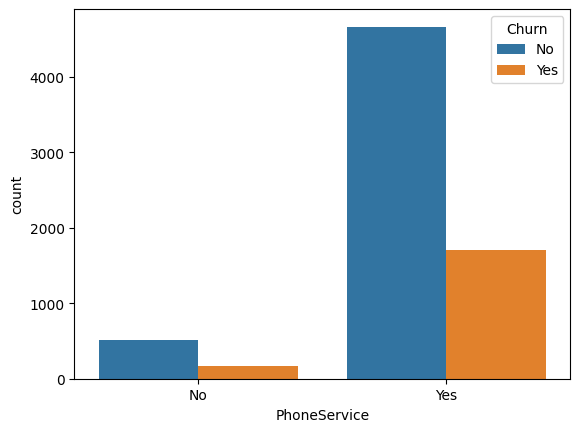

Churn                No        Yes
PhoneService                      
No            75.073314  24.926686
Yes           73.290363  26.709637
****************************************************************************************************
MultipleLines Vs Churn


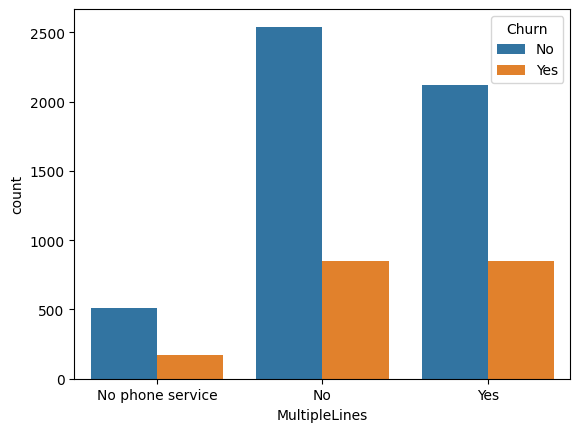

Churn                    No        Yes
MultipleLines                         
No                74.955752  25.044248
No phone service  75.073314  24.926686
Yes               71.390104  28.609896
****************************************************************************************************
InternetService Vs Churn


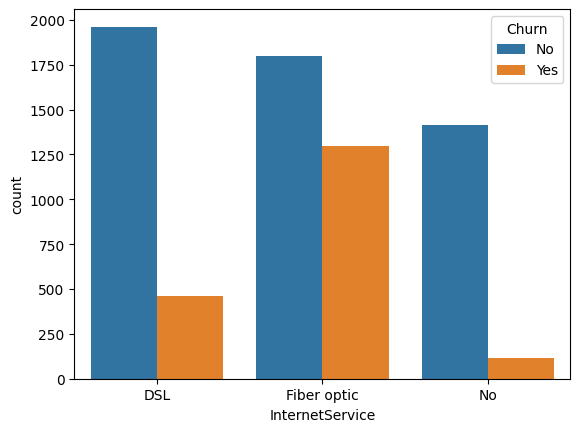

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980
****************************************************************************************************
OnlineSecurity Vs Churn


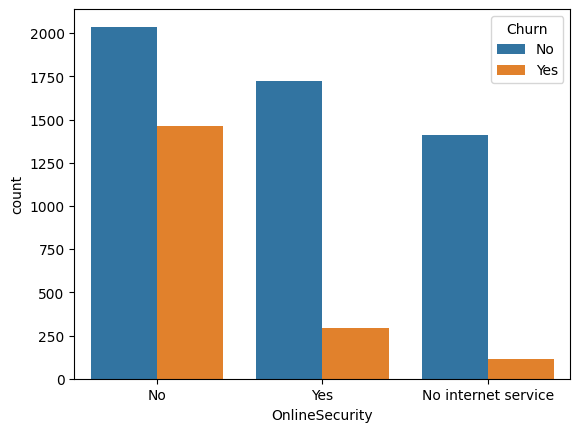

Churn                       No        Yes
OnlineSecurity                           
No                   58.233276  41.766724
No internet service  92.595020   7.404980
Yes                  85.388806  14.611194
****************************************************************************************************
OnlineBackup Vs Churn


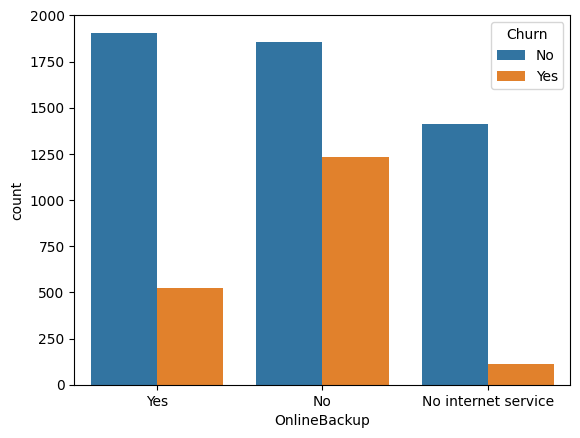

Churn                       No        Yes
OnlineBackup                             
No                   60.071244  39.928756
No internet service  92.595020   7.404980
Yes                  78.468506  21.531494
****************************************************************************************************
DeviceProtection Vs Churn


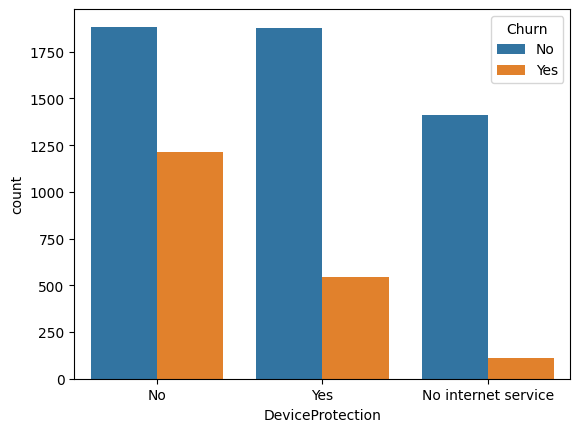

Churn                       No        Yes
DeviceProtection                         
No                   60.872375  39.127625
No internet service  92.595020   7.404980
Yes                  77.497936  22.502064
****************************************************************************************************
TechSupport Vs Churn


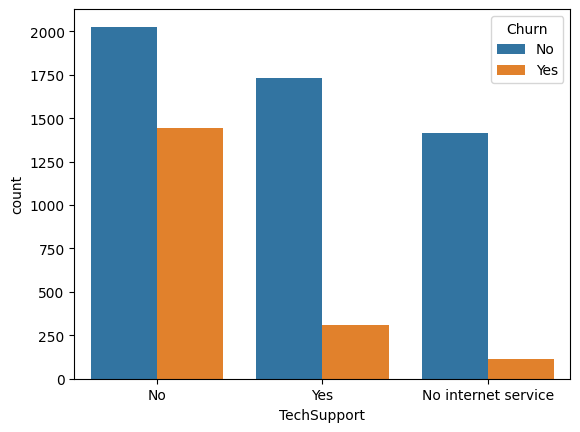

Churn                       No        Yes
TechSupport                              
No                   58.364526  41.635474
No internet service  92.595020   7.404980
Yes                  84.833659  15.166341
****************************************************************************************************
StreamingTV Vs Churn


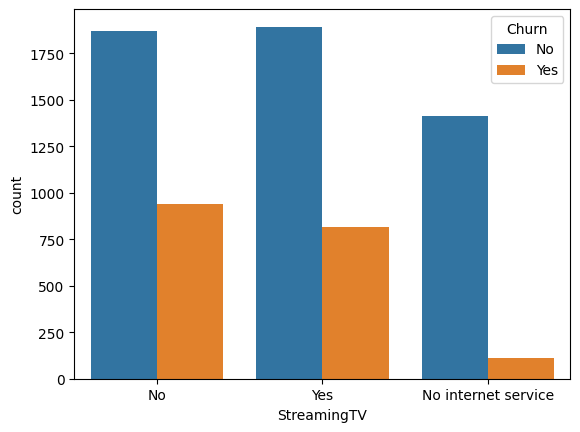

Churn                       No        Yes
StreamingTV                              
No                   66.476868  33.523132
No internet service  92.595020   7.404980
Yes                  69.929812  30.070188
****************************************************************************************************
StreamingMovies Vs Churn


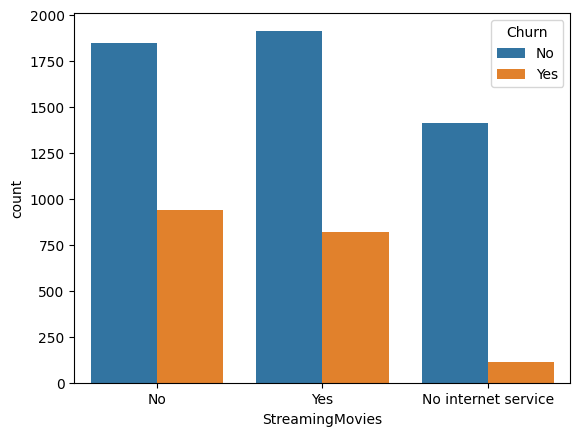

Churn                       No        Yes
StreamingMovies                          
No                   66.319569  33.680431
No internet service  92.595020   7.404980
Yes                  70.058565  29.941435
****************************************************************************************************
Contract Vs Churn


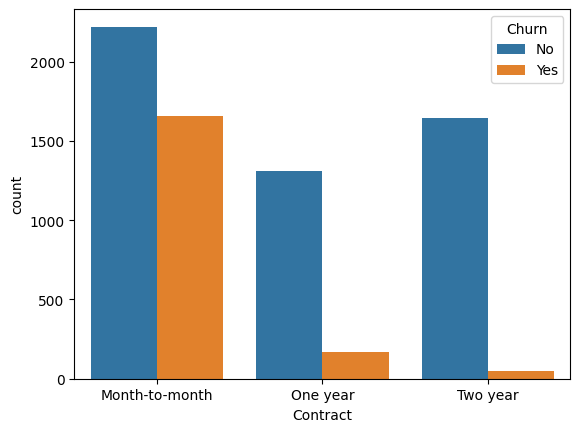

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
****************************************************************************************************
PaperlessBilling Vs Churn


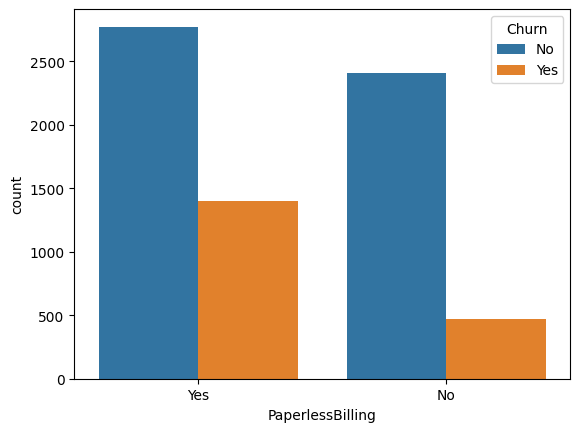

Churn                    No        Yes
PaperlessBilling                      
No                83.669916  16.330084
Yes               66.434908  33.565092
****************************************************************************************************
PaymentMethod Vs Churn


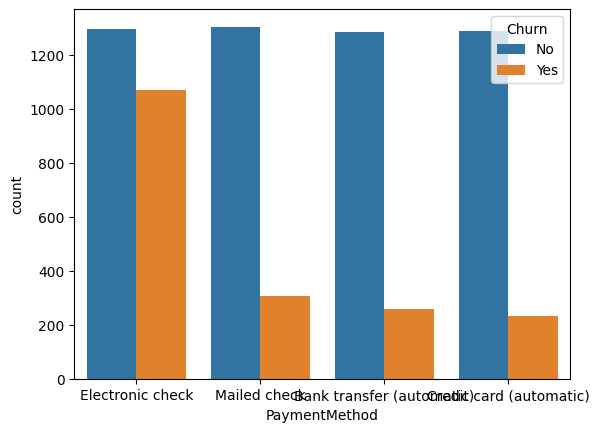

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700
****************************************************************************************************
Churn Vs Churn


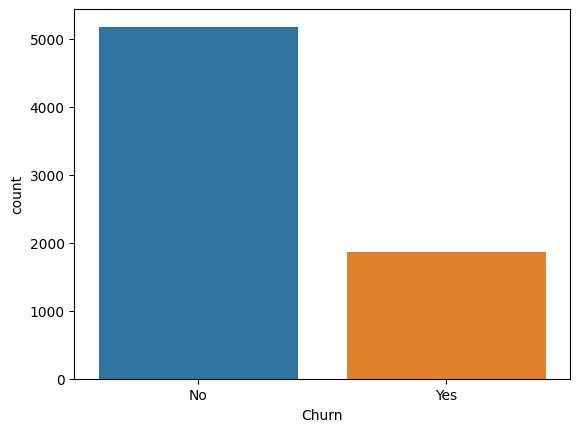

Churn     No    Yes
Churn              
No     100.0    0.0
Yes      0.0  100.0
****************************************************************************************************
SeniorCitizen Vs Churn


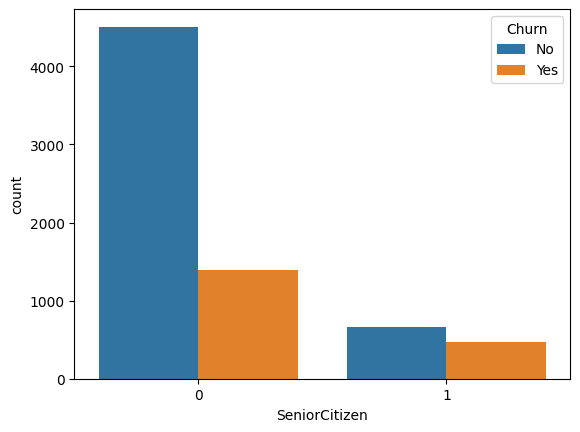

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261
****************************************************************************************************


In [146]:
def bivariant_analysis_cat(df):
    for col in cat_col:
        print(f"{col} Vs Churn")
        #Countplot diff
        sns.countplot(x=col,hue='Churn',data=df)
        plt.show()

        #Percentage Of Impact of specific feature on Churn 
        print(pd.crosstab(df[col],df['Churn'],normalize='index')*100)
        print("*"*100)

bivariant_analysis_cat(df)

# Bivariant Analysis - Num Col 

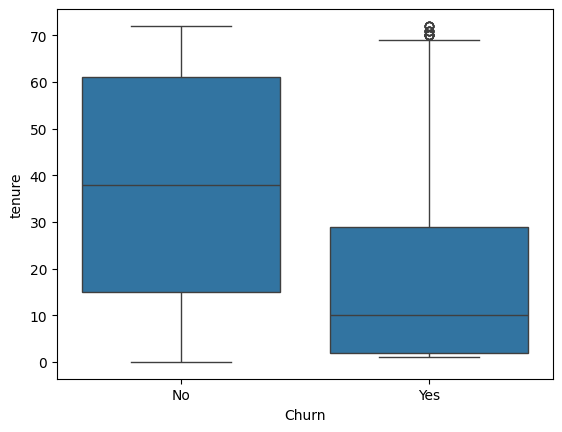

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64


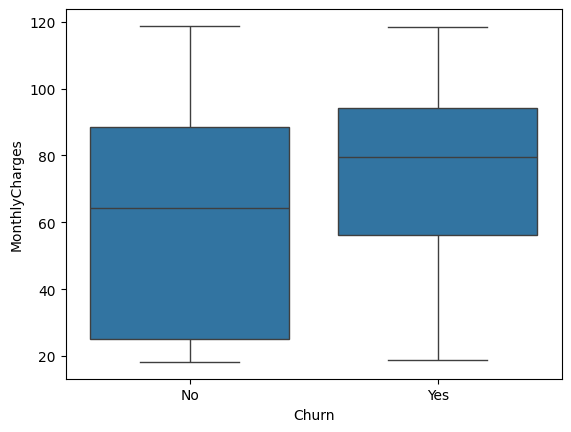

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


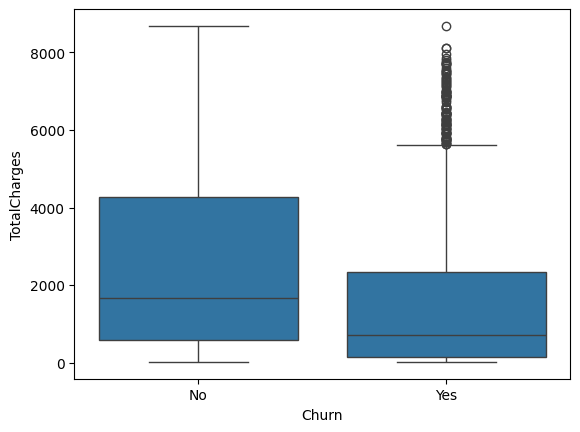

Churn
No     2552.882494
Yes    1531.796094
Name: TotalCharges, dtype: float64


In [147]:
# Num Col
def bivariant_num_col(df):
    for col in num_col:
        sns.boxplot(x='Churn',y=col,data=df)
        plt.show()

        #Groupby
        print(df.groupby('Churn')[col].mean())
bivariant_num_col(df)

# Bivariate Analysis Insights



# Categorical Features



## gender

### WHAT THIS MEANS

* Female churn ≈ 26.9%
* Male churn ≈ 26.1%

### INTERPRETATION

* Churn difference is very small between genders

### BUSINESS INSIGHT

* Gender does not influence customer churn

### FINAL NOTE

* Low impact feature
* Can be ignored or given low priority

---

## Partner

### WHAT THIS MEANS

* No partner → 32.9% churn
* Has partner → 19.6% churn

### INTERPRETATION

* Customers without partners churn more

### BUSINESS INSIGHT

* Customers without partners are less stable and more likely to leave

### FINAL NOTE

* Medium to high impact feature
* Important for model

---

## Dependents

### WHAT THIS MEANS

* No dependents → 31.2% churn
* Has dependents → 15.4% churn

### INTERPRETATION

* Customers without dependents churn more

### BUSINESS INSIGHT

* Independent customers are more flexible to switch services

### FINAL NOTE

* High impact feature

---

## PhoneService

### WHAT THIS MEANS

* No → 24.9% churn
* Yes → 26.7% churn

### INTERPRETATION

* Very small difference

### BUSINESS INSIGHT

* Phone service usage does not affect churn

### FINAL NOTE

* Low impact feature
* Can be removed

---

## MultipleLines

### WHAT THIS MEANS

* Yes → 28.6% churn
* No → 25% churn

### INTERPRETATION

* Slight difference in churn

### BUSINESS INSIGHT

* Having multiple lines has minimal influence

### FINAL NOTE

* Low to medium impact

---

## InternetService

### WHAT THIS MEANS

* Fiber optic → 41.8% churn
* DSL → 18.9% churn
* No internet → 7.4% churn

### INTERPRETATION

* Fiber users churn significantly more

### BUSINESS INSIGHT

* Type of internet service strongly affects churn behavior

### FINAL NOTE

* High impact feature

---

## OnlineSecurity

### WHAT THIS MEANS

* No → 41.7% churn
* Yes → 14.6% churn

### INTERPRETATION

* Customers without security churn more

### BUSINESS INSIGHT

* Lack of security service increases churn risk

### FINAL NOTE

* High impact feature

---

## OnlineBackup

### WHAT THIS MEANS

* No → 39.9% churn
* Yes → 21.5% churn

### INTERPRETATION

* Customers without backup churn more

### BUSINESS INSIGHT

* Additional services improve retention

### FINAL NOTE

* Medium to high impact

---

## DeviceProtection

### WHAT THIS MEANS

* No → 39.1% churn
* Yes → 22.5% churn

### INTERPRETATION

* Customers without protection churn more

### BUSINESS INSIGHT

* Device protection reduces churn risk

### FINAL NOTE

* Medium to high impact

---

## TechSupport

### WHAT THIS MEANS

* No → 41.6% churn
* Yes → 15.1% churn

### INTERPRETATION

* Customers without support churn more

### BUSINESS INSIGHT

* Technical support is critical for retention

### FINAL NOTE

* High impact feature

---

## StreamingTV / StreamingMovies

### WHAT THIS MEANS

* Churn around 30–33% for both

### INTERPRETATION

* Very small variation

### BUSINESS INSIGHT

* Streaming services do not strongly influence churn

### FINAL NOTE

* Low impact feature

---

## Contract

### WHAT THIS MEANS

* Month-to-month → 42.7% churn
* One year → 11.2% churn
* Two year → 2.8% churn

### INTERPRETATION

* Short-term customers churn more

### BUSINESS INSIGHT

* Long-term contracts improve customer retention

### FINAL NOTE

* Very high impact feature
* One of the most important features

---

## PaperlessBilling

### WHAT THIS MEANS

* Yes → 33.5% churn
* No → 16.3% churn

### INTERPRETATION

* Paperless users churn more

### BUSINESS INSIGHT

* Billing method may influence customer behavior

### FINAL NOTE

* Medium impact

---

## PaymentMethod

### WHAT THIS MEANS

* Electronic check → 45.2% churn
* Others → ~15–19% churn

### INTERPRETATION

* Electronic check users churn more

### BUSINESS INSIGHT

* Payment method strongly impacts churn

### FINAL NOTE

* High impact feature

---

## SeniorCitizen

### WHAT THIS MEANS

* Yes → 41.6% churn
* No → 23.6% churn

### INTERPRETATION

* Senior citizens churn more

### BUSINESS INSIGHT

* Older customers show different behavior

### FINAL NOTE

* Medium to high impact

---

# Numerical Features



## tenure

### WHAT THIS MEANS

* Customers who stayed → ~37 months
* Customers who churned → ~18 months

### INTERPRETATION

* Customers with lower tenure churn more

### BUSINESS INSIGHT

* New customers are at higher risk of leaving
* Long-term customers are more loyal

### FINAL NOTE

* High impact feature

---

## MonthlyCharges

### WHAT THIS MEANS

* Customers who stayed → ~61
* Customers who churned → ~74

### INTERPRETATION

* Customers paying higher charges churn more

### BUSINESS INSIGHT

* High-paying customers have higher expectations
* If not satisfied, they are more likely to leave

### FINAL NOTE

* Medium to high impact feature

---

## TotalCharges

### WHAT THIS MEANS

* Wide variation across customers

### INTERPRETATION

* Not meaningful in categorical comparison

### BUSINESS INSIGHT

* Represents total customer value over time

### FINAL NOTE

* Treat as numerical feature
* Important for modeling

---

# ## Final Understanding

* High impact features: Contract, tenure, InternetService, TechSupport, OnlineSecurity, PaymentMethod
* Medium impact: MonthlyCharges, Partner, Dependents, PaperlessBilling
* Low impact: gender, PhoneService, Streaming features




# EDA
# Step 6: Multivariate Analysis 
* To detect multicollinearity (features giving same info)
* Helps in feature selection
* Avoids model confusion

## What is Correlation?

👉 It tells:

How strongly two numerical variables are related

👉 Range:

- +1 → strong positive relation
- 0 → no relation
- -1 → strong negative relation

- Note : Corelation can only be used for Numerical Features not for Categoral Features 

In [150]:
#df[[ ]].corr()
df[['tenure', 'MonthlyCharges', 'TotalCharges']] #select only numerical col

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65
...,...,...,...
7038,24,84.80,1990.50
7039,72,103.20,7362.90
7040,11,29.60,346.45
7041,4,74.40,306.60


In [151]:
df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

#insight :
'''
=>> How To analyse the above the Correlation:
1. 1st observe the matrix -> it tells how the 2 columns are strongly Corelated : 
->  +1 -> +ve -> both Col r travelling in the same direction
->  -1 -> -ve -> 2 Col r travelling in Diff Direction -> 1 above 1 below
->  0  -> No Relationship 

2. Take 2 col
3. Observe the value
4. 

'''

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.825464
MonthlyCharges,0.247900,1.000000,0.650864
TotalCharges,0.825464,0.650864,1.000000


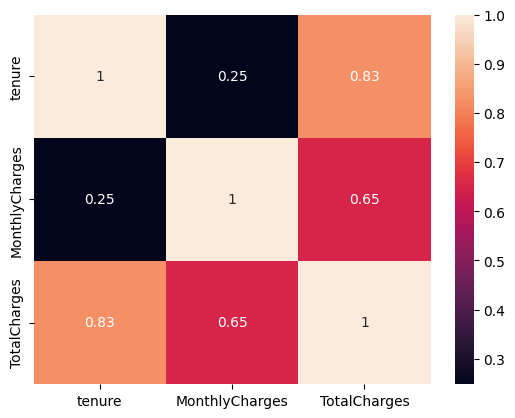

In [154]:
#visualize:
# sns.heatmap(output,annot=True) #Meaning of Annote=True ->> Annote means -> annotate ..means by default heatmap only shows the colour intensity but annote add the exact numerical corr value inside each cell making it more precise and visible , by defalt annote=False so to use it ..make annote=true  
sns.heatmap(df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),annot=True)
plt.show()